## 1. House Price & Category Prediction 
Zeeshan Ahmed
24F-AI-215


========== DATASET ==========
Shape: (1460, 81)

First 5 rows:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  Yr

C:\Users\pc\AppData\Local\Temp\ipykernel_15376\2875609254.py:160: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train_clean.select_dtypes(


Random Forest Classifier trained successfully.

========== RANDOM FOREST PERFORMANCE ==========
Accuracy: 0.7945
Accuracy: 79.45%

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.87      0.86        97
         Low       0.84      0.80      0.82        97
      Medium       0.69      0.71      0.70        98

    accuracy                           0.79       292
   macro avg       0.80      0.79      0.80       292
weighted avg       0.80      0.79      0.80       292


Confusion Matrix:
[[78 18  1]
 [15 70 13]
 [ 0 13 84]]


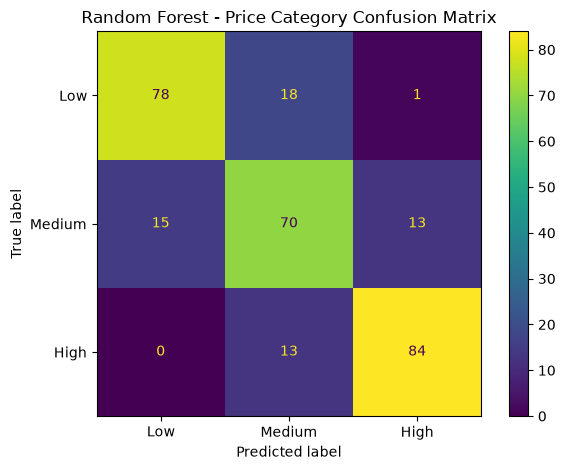

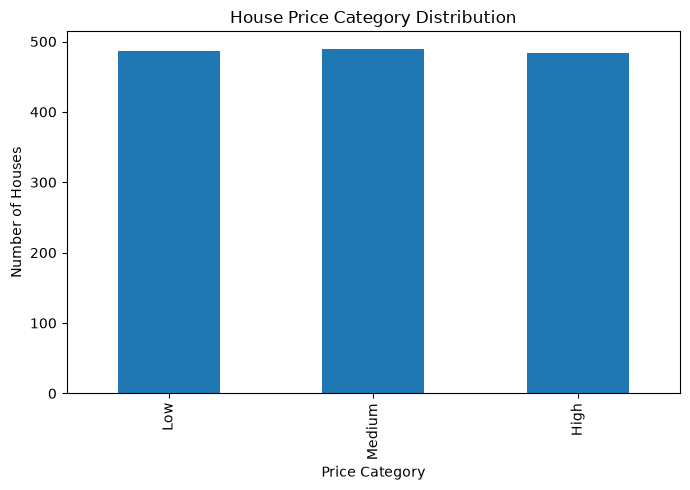


Final category prediction file created:
random_forest_price_category_predictions.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(r"E:\Online Courses\ML_Lab_Work\Machine_Learning_Lab_Work\Lab_07\train.csv")


print("\n========== DATASET ==========")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 2. EXPLORE DATA
# ============================================================

print("\n========== DATA INFORMATION ==========")
df.info()

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:", df.duplicated().sum())


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates().copy()


# ============================================================
# 4. CREATE PRICE CATEGORY
# ============================================================

# The original dataset gives SalePrice as a continuous value.
# For classification, we convert it into 3 categories:
#
# Low    = bottom third of house prices
# Medium = middle third
# High   = top third
#
# The thresholds are calculated from SalePrice in the training
# dataset supplied for this project.

low_limit = df["SalePrice"].quantile(1 / 3)
high_limit = df["SalePrice"].quantile(2 / 3)

def make_category(price):
    if price <= low_limit:
        return "Low"
    elif price <= high_limit:
        return "Medium"
    else:
        return "High"

df["PriceCategory"] = df["SalePrice"].apply(make_category)

print("\n========== PRICE CATEGORY ==========")
print("Low limit   :", low_limit)
print("High limit  :", high_limit)
print(df["PriceCategory"].value_counts())


# ============================================================
# 5. SEPARATE FEATURES AND TARGET
# ============================================================

# SalePrice is removed because it directly determines the
# category and would cause target leakage.
X = df.drop(["SalePrice", "PriceCategory"], axis=1)
y = df["PriceCategory"]

if "Id" in X.columns:
    X = X.drop("Id", axis=1)


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========== DATA SPLIT ==========")
print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))


# ============================================================
# 7. OUTLIER REMOVAL
# ============================================================

# Outlier removal is performed only on the training data.
# We use IQR for important numeric house-size variables.

outlier_columns = [
    col for col in [
        "GrLivArea",
        "TotalBsmtSF",
        "GarageArea",
        "1stFlrSF",
        "LotArea"
    ]
    if col in X_train.columns
]

train_clean = X_train.copy()
y_train_clean = y_train.copy()

for col in outlier_columns:
    q1 = train_clean[col].quantile(0.25)
    q3 = train_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = train_clean[col].isna() | train_clean[col].between(lower, upper)

    train_clean = train_clean.loc[mask]
    y_train_clean = y_train_clean.loc[train_clean.index]

print("\nTraining rows after outlier removal:", len(train_clean))


# ============================================================
# 8. IDENTIFY COLUMN TYPES
# ============================================================

numeric_features = train_clean.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = train_clean.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


# ============================================================
# 9. DATA PREPROCESSING
# ============================================================

# Numeric:
#   Missing values -> median
#   Scaling -> StandardScaler
#
# Categorical:
#   Missing values -> most frequent
#   Encoding -> One-Hot Encoding

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])


# ============================================================
# 10. BUILD RANDOM FOREST CLASSIFIER
# ============================================================

model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])


# ============================================================
# 11. TRAIN MODEL
# ============================================================

print("\n========== TRAINING ==========")
model.fit(train_clean, y_train_clean)

print("Random Forest Classifier trained successfully.")


# ============================================================
# 12. TEST MODEL
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 13. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n========== RANDOM FOREST PERFORMANCE ==========")
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"]
)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot()
plt.title("Random Forest - Price Category Confusion Matrix")
plt.tight_layout()
plt.show()


# ============================================================
# 15. PRICE CATEGORY DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))
df["PriceCategory"].value_counts().reindex(
    ["Low", "Medium", "High"]
).plot(kind="bar")
plt.xlabel("Price Category")
plt.ylabel("Number of Houses")
plt.title("House Price Category Distribution")
plt.tight_layout()
plt.show()


# ============================================================
# 16. FINAL CATEGORY PREDICTION FOR test.csv
# ============================================================

try:
    external_test = pd.read_csv("test.csv")

    ids = external_test["Id"].copy()

    if "Id" in external_test.columns:
        external_features = external_test.drop("Id", axis=1)
    else:
        external_features = external_test

    category_predictions = model.predict(external_features)

    category_submission = pd.DataFrame({
        "Id": ids,
        "PriceCategory": category_predictions
    })

    category_submission.to_csv(
        "random_forest_price_category_predictions.csv",
        index=False
    )

    print("\nFinal category prediction file created:")
    print("random_forest_price_category_predictions.csv")

except FileNotFoundError:
    print("\ntest.csv was not found. Final category prediction file skipped.")
